In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib

from scipy import stats

import hdbscan
import pacmap

from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn import tree

from sklearn import metrics

# Load data

In [4]:
data = pd.read_csv('data/flowmeter_A.txt', sep="\t", header=None).dropna()

data.describe()

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,...,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,0.824482,1.012743,0.997459,4.682436,5.754454,5.650059,4.689737,4.739781,5.746312,5.648517,...,32.506978,34.023157,33.205913,36.667715,36.791768,35.946106,35.920962,34.256859,32.913075,1.597701
std,0.018146,0.007418,0.002046,1.800595,2.224012,2.188446,1.835339,1.834655,2.218003,2.188067,...,0.097678,0.230991,0.106636,0.019964,0.078697,0.057946,0.044998,0.371358,0.141770,0.493204
min,0.790194,0.997058,0.993241,1.781262,2.247824,2.234464,1.785612,1.767456,2.261254,2.238488,...,32.267253,33.709312,33.001302,36.629232,36.678060,35.843100,35.828452,33.668622,32.641603,1.000000
25%,0.809688,1.008405,0.995865,2.855605,3.454327,3.383418,2.824120,2.873642,3.447957,3.381488,...,32.430013,33.803711,33.114420,36.658528,36.723634,35.913086,35.898437,33.907062,32.806803,1.000000
50%,0.833332,1.013437,0.997486,5.361665,6.796140,6.664992,5.431951,5.433235,6.785348,6.670478,...,32.501627,34.060872,33.172202,36.666667,36.801757,35.934243,35.913087,34.334312,32.875978,2.000000
75%,0.840179,1.018409,0.998824,5.665208,6.836397,6.711797,5.662967,5.732180,6.817800,6.725551,...,32.592775,34.121093,33.301596,36.679688,36.831870,35.983072,35.947267,34.468587,33.052572,2.000000
max,0.847096,1.028315,1.002573,8.469805,10.287437,10.128200,8.591271,8.581726,10.299377,10.113305,...,32.693685,34.627278,33.426105,36.728517,37.005208,36.127928,36.056315,35.174155,33.185218,2.000000


/var/folders/q5/6txyk4317txfn_vkvk6sbl9m0000gn/T/ipykernel_35789/3927987917.py:8: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  matrix = pd.plotting.scatter_matrix(data, color = 'k', diagonal = 'kde', ax = axs0)
/var/folders/q5/6txyk4317txfn_vkvk6sbl9m0000gn/T/ipykernel_35789/3927987917.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn', len(correlation_list))    # PiYG


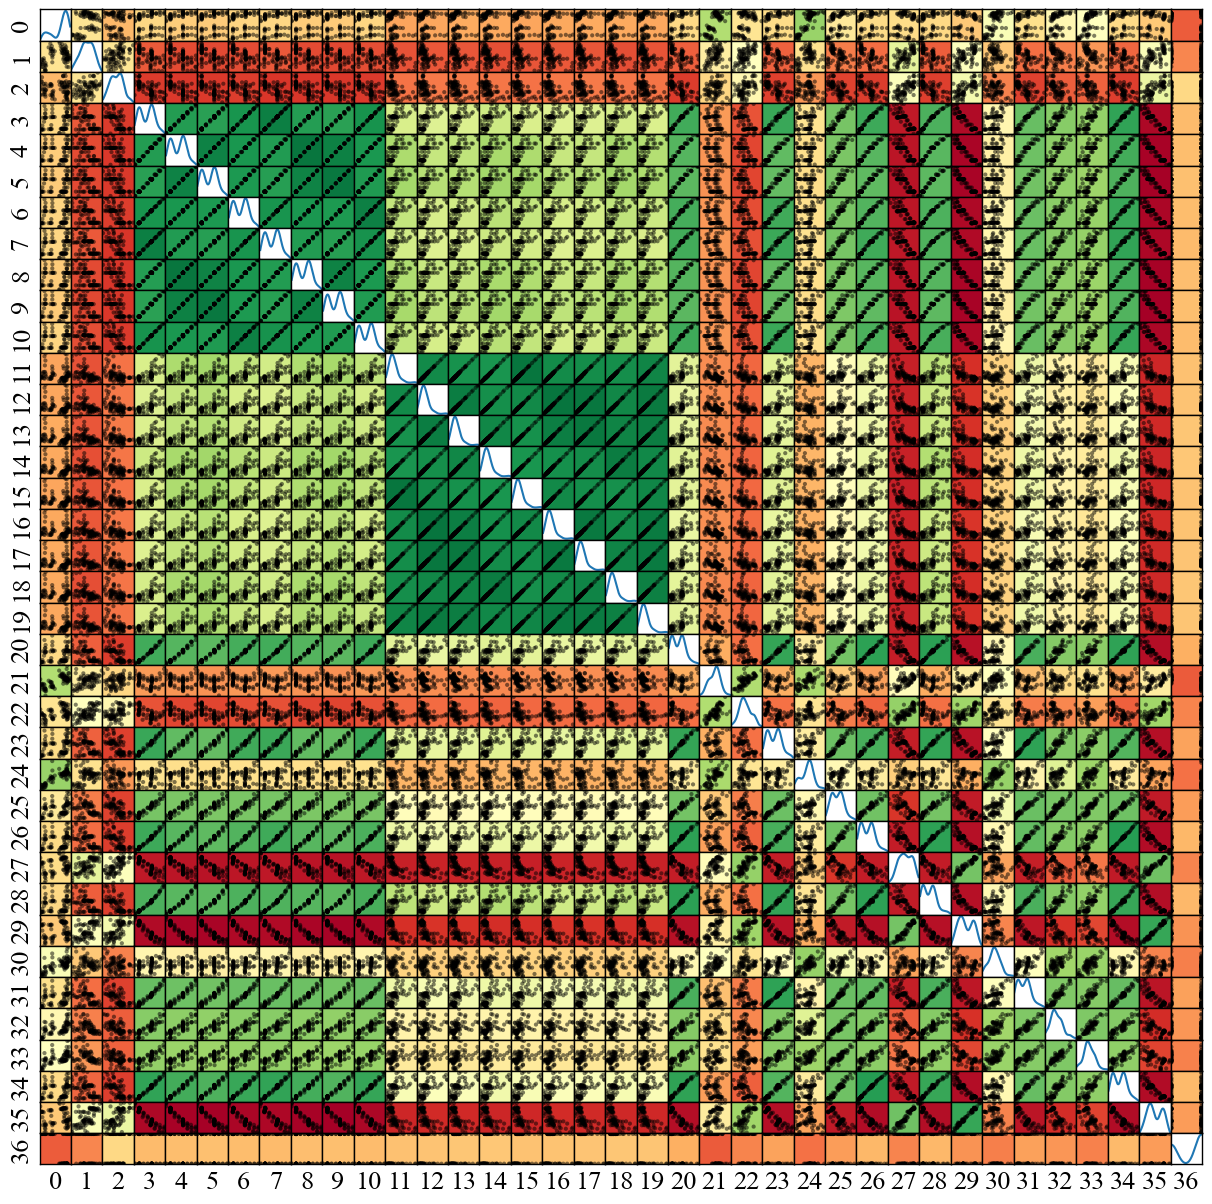

In [6]:
def plot_matrix(data):

    n = len(data)*len(data.columns)

    fig = plt.figure(figsize = (15, 15))
    axs0 = fig.add_subplot(1, 2, 1)

    matrix = pd.plotting.scatter_matrix(data, color = 'k', diagonal = 'kde', ax = axs0)

    correlation = data.corr()
    #print(correlation)

    correlation_list = np.asarray(correlation).flatten().tolist()

    correlation_list.sort()

    cmap = cm.get_cmap('RdYlGn', len(correlation_list))    # PiYG

    colors = []
    for i in range(cmap.N):
        rgba = cmap(i)
        # rgb2hex accepts rgb or rgba
        colors.append(matplotlib.colors.rgb2hex(rgba))

    colors_dict = dict(zip(correlation_list, colors))

    for ax in fig.get_axes():

        x = ax.xaxis.get_label().get_text()
        y = ax.yaxis.get_label().get_text()

        #print(int(x), int(y))
        
        corr = correlation[int(x)][int(y)]
        #print(corr)
        if x != y:
            ax.set_facecolor(colors_dict[corr])

        # xmin, xmax = ax.get_xlim()
        # ymin, ymax = ax.get_ylim()


        ax.xaxis.set_tick_params(labelbottom=False)
        ax.yaxis.set_tick_params(labelleft=False)

        ax.set_xticks([])
        ax.set_yticks([])

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=19
    plt.rcParams['axes.linewidth'] = 1 
    plt.xticks(rotation = 45)
    plt.yticks(rotation = 45)
    #plt.legend(frameon = False)
    #plt.tight_layout()
    plt.savefig(f'figures/example-6-1-matrix.png', dpi = 300)
    plt.show()

    return None

plot_matrix(data)


# Preprocess data

In [7]:
data = data.to_numpy()

x = data[:, :-1]
y = data[:, -1]

#We want classes to be 0 and 1
for i in range(len(y)):
    if y[i] == 1:
        y[i] = 0

    else:
        y[i] = 1

#Data preprocessing
scaler = StandardScaler()
x = scaler.fit_transform(x)

#Create train and test datasets
X_train, X_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.5,
                                                    shuffle=True, 
                                                    random_state=74)

# Train a decision tree model

In [8]:
#Create DT model
DT_classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)

#Train the model
DT_classifier.fit(X_train, y_train)

#Test the model
DT_predicted = DT_classifier.predict(X_test)

DT_accuracy = metrics.accuracy_score(y_test, DT_predicted)

print(DT_accuracy)


0.9318181818181818



# Train a support vector machine model

In [9]:
#Create SVC model
SVC_classifier = SVC(random_state = 42)

#Train the model
SVC_classifier.fit(X_train, y_train)

#Test the model
SVC_predicted = SVC_classifier.predict(X_test)

SVC_accuracy = metrics.accuracy_score(y_test, SVC_predicted)

print(SVC_accuracy)

0.75


# Train an artificial neural network (MLP) model

In [10]:
#Create MLP model
MLP_classifier = MLPClassifier(random_state = 42, max_iter=3000)

#Train the model
MLP_classifier.fit(X_train, y_train)

#Test the model
MLP_predicted = MLP_classifier.predict(X_test)

MLP_accuracy = metrics.accuracy_score(y_test, MLP_predicted)

print(MLP_accuracy)




0.8181818181818182


# Compare results with default hyperparameters

In [11]:
def plot_roc(clfs, test = 'default'):

    fig = plt.figure(figsize=(6, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    for clf in clfs:
        metrics.RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=axs0, linewidth = 1)

    axs0.xaxis.label.set_size('medium')
    axs0.yaxis.label.set_size('medium')

    axs0.tick_params(direction='out',
                            pad=10,
                            length=9,
                            width=1,
                            labelsize='medium')

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='medium')

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1 
    plt.legend(frameon = False)
    plt.tight_layout()
    plt.savefig(f'figures/example-6-1-{test}.png', dpi = 300)
    plt.show()

    return None

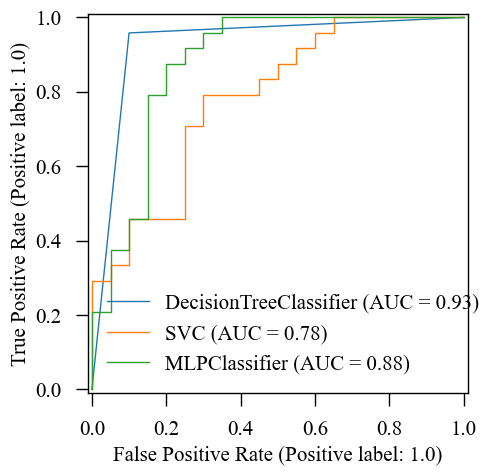

In [13]:
clfs = [
        DT_classifier,
        SVC_classifier,
        MLP_classifier
    ]
    
plot_roc(clfs)

## Get model structures

[Text(0.2857142857142857, 0.9, 'x[0] <= -0.142\nentropy = 0.933\nsamples = 43\nvalue = [15.0, 28.0]'),
 Text(0.14285714285714285, 0.7, 'entropy = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.21428571428571427, 0.8, 'True  '),
 Text(0.42857142857142855, 0.7, 'x[16] <= -0.533\nentropy = 0.932\nsamples = 23\nvalue = [15, 8]'),
 Text(0.3571428571428571, 0.8, '  False'),
 Text(0.2857142857142857, 0.5, 'entropy = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.5714285714285714, 0.5, 'x[2] <= -0.682\nentropy = 0.961\nsamples = 13\nvalue = [5, 8]'),
 Text(0.42857142857142855, 0.3, 'entropy = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.7142857142857143, 0.3, 'x[16] <= 0.769\nentropy = 0.503\nsamples = 9\nvalue = [1, 8]'),
 Text(0.5714285714285714, 0.1, 'entropy = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.8571428571428571, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]')]

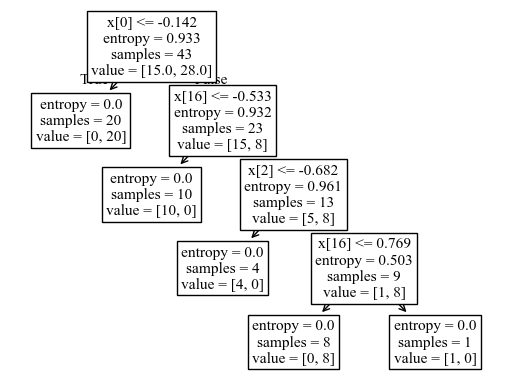

In [15]:
tree.plot_tree(DT_classifier)

In [18]:
SVC_classifier.support_vectors_.shape

(31, 36)

In [19]:
for i, layer in enumerate(MLP_classifier.coefs_):
    print(f'layer_{i}: {len(MLP_classifier.coefs_[i])}')

layer_0: 36
layer_1: 100


# Performance with improved hyperparameters

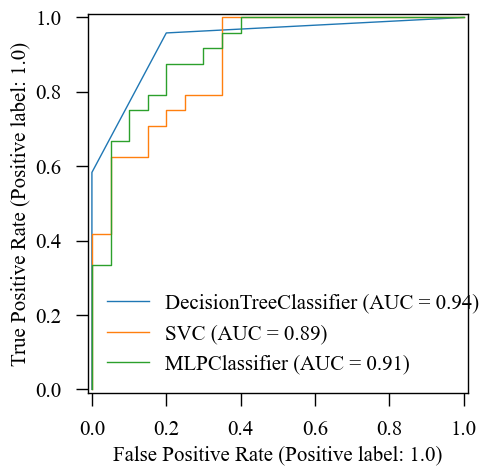

In [20]:
DT_classifier_improved = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3, random_state = 42)
SVC_classifier_improved = SVC(C = 5, random_state = 42)
MLP_classifier_improved = MLPClassifier(hidden_layer_sizes = (10, ), random_state = 42, max_iter=3000)

clfs_improved = [
    DT_classifier_improved, 
    SVC_classifier_improved,
    MLP_classifier_improved
]

for clf in clfs_improved:
    #Train the model
    clf.fit(X_train, y_train)

plot_roc(clfs_improved, test = 'improved')

## Get model structures

[Text(0.3333333333333333, 0.875, 'x[0] <= -0.142\nentropy = 0.933\nsamples = 43\nvalue = [15.0, 28.0]'),
 Text(0.16666666666666666, 0.625, 'entropy = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[16] <= -0.533\nentropy = 0.932\nsamples = 23\nvalue = [15, 8]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'entropy = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.6666666666666666, 0.375, 'x[2] <= -0.682\nentropy = 0.961\nsamples = 13\nvalue = [5, 8]'),
 Text(0.5, 0.125, 'entropy = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.8333333333333334, 0.125, 'entropy = 0.503\nsamples = 9\nvalue = [1, 8]')]

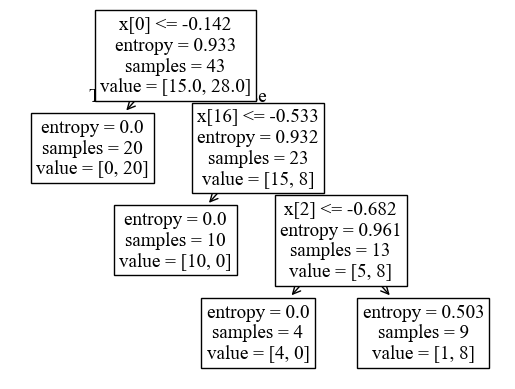

In [21]:
tree.plot_tree(DT_classifier_improved)

In [24]:
SVC_classifier_improved.support_vectors_.shape

(25, 36)

In [23]:
for i, layer in enumerate(MLP_classifier_improved.coefs_):
    print(f'layer_{i}: {len(MLP_classifier_improved.coefs_[i])})')

layer_0: 36)
layer_1: 10)
